In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv(r'.\TrainingWiDS2021.csv')
# Đặt tên biến mục tiêu của bạn (Thay 'target' bằng tên cột thực tế trong WiDS, vd: 'hospital_death')
TARGET_COL = 'diabetes_mellitus' 


In [2]:
print(data.columns.to_list())

['Unnamed: 0', 'encounter_id', 'hospital_id', 'age', 'bmi', 'elective_surgery', 'ethnicity', 'gender', 'height', 'hospital_admit_source', 'icu_admit_source', 'icu_id', 'icu_stay_type', 'icu_type', 'pre_icu_los_days', 'readmission_status', 'weight', 'albumin_apache', 'apache_2_diagnosis', 'apache_3j_diagnosis', 'apache_post_operative', 'arf_apache', 'bilirubin_apache', 'bun_apache', 'creatinine_apache', 'fio2_apache', 'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_unable_apache', 'gcs_verbal_apache', 'glucose_apache', 'heart_rate_apache', 'hematocrit_apache', 'intubated_apache', 'map_apache', 'paco2_apache', 'paco2_for_ph_apache', 'pao2_apache', 'ph_apache', 'resprate_apache', 'sodium_apache', 'temp_apache', 'urineoutput_apache', 'ventilated_apache', 'wbc_apache', 'd1_diasbp_invasive_max', 'd1_diasbp_invasive_min', 'd1_diasbp_max', 'd1_diasbp_min', 'd1_diasbp_noninvasive_max', 'd1_diasbp_noninvasive_min', 'd1_heartrate_max', 'd1_heartrate_min', 'd1_mbp_invasive_max', 'd1_mbp_invasive_min',

In [2]:
data

,Unnamed: 0,encounter_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,hospital_admit_source,...,h1_pao2fio2ratio_max,h1_pao2fio2ratio_min,aids,cirrhosis,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,diabetes_mellitus
0,1,214826,118,68.0,22.732803,0,Caucasian,M,180.3,Floor,...,NaN,NaN,0,0,0,0,0,0,0,1
1,2,246060,81,77.0,27.421875,0,Caucasian,F,160.0,Floor,...,51.0,51.0,0,0,0,0,0,0,0,1
2,3,276985,118,25.0,31.952749,0,Caucasian,F,172.7,Emergency Department,...,NaN,NaN,0,0,0,0,0,0,0,0
3,4,262220,118,81.0,22.635548,1,Caucasian,F,165.1,Operating Room,...,337.0,337.0,0,0,0,0,0,0,0,0
4,5,201746,33,19.0,NaN,0,Caucasian,M,188.0,NaN,...,NaN,NaN,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130152,130153,164758,7,50.0,29.287256,0,Caucasian,M,175.3,Emergency Department,...,NaN,NaN,0,0,0,0,0,0,0,0
130153,130154,197653,7,79.0,29.653433,0,Caucasian,F,162.6,Direct Admit,...,NaN,NaN,0,0,0,0,0,0,0,0
130154,130155,219719,7,73.0,32.265371,0,African American,M,177.8,Emergency Department,...,163.0,163.0,0,0,0,0,0,0,0,1
130155,130156,222562,170,81.0,24.408579,0,Caucasian,M,185.4,Emergency Department,...,NaN,NaN,0,0,0,0,0,0,0,0


--- 1. THỐNG KÊ MISSING VALUES ---
Top 10 cột bị khuyết dữ liệu nhiều nhất (%):
h1_bilirubin_min        92.089553
h1_bilirubin_max        92.089553
h1_albumin_min          91.431886
h1_albumin_max          91.431886
h1_lactate_min          91.018539
h1_lactate_max          91.018539
h1_pao2fio2ratio_min    87.123243
h1_pao2fio2ratio_max    87.123243
h1_arterial_ph_max      82.860699
h1_arterial_ph_min      82.860699
dtype: float64
-> Tổng số cột bị khuyết > 80% dữ liệu: 32 cột.

--- 2. TỶ LỆ MẤT CÂN BẰNG BIẾN MỤC TIÊU ---
diabetes_mellitus
0    78.371505
1    21.628495
Name: proportion, dtype: float64


--- 3. MA TRẬN ĐA CỘNG TUYẾN ---
-> Tổng số cặp đặc trưng có hệ số tương quan > 0.9: 91 cặp.



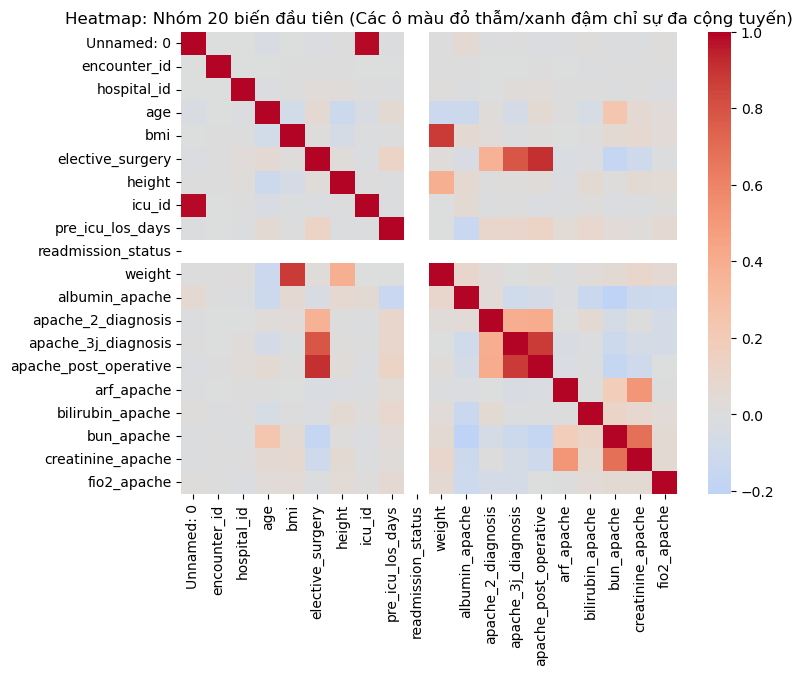

--- 4. KIỂM ĐỊNH NGOẠI LAI (MIN/MAX BẤT THƯỜNG) ---
Thống kê mô tả một số cột:
                              min           mean            max
Unnamed: 0               1.000000   65079.000000  130157.000000
encounter_id        147000.000000  213000.856519  279000.000000
hospital_id              1.000000     106.102131     204.000000
age                      0.000000      61.995103      89.000000
bmi                     14.844926      29.110260      67.814990
elective_surgery         0.000000       0.189840       1.000000
height                 137.200000     169.607219     195.590000
icu_id                  82.000000     662.428344    1111.000000
pre_icu_los_days        -0.250000       0.839933     175.627778
readmission_status       0.000000       0.000000       0.000000


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv(r'.\TrainingWiDS2021.csv')
# Đặt tên biến mục tiêu của bạn (Thay 'target' bằng tên cột thực tế trong WiDS, vd: 'hospital_death')
TARGET_COL = 'diabetes_mellitus' 

# ---------------------------------------------------------
# 1. CHỨNG MINH MISSING VALUES KHỔNG LỒ
# ---------------------------------------------------------
print("--- 1. THỐNG KÊ MISSING VALUES ---")
missing_percent = data.isnull().mean() * 100
print("Top 10 cột bị khuyết dữ liệu nhiều nhất (%):")
print(missing_percent.sort_values(ascending=False).head(10))
print(f"-> Tổng số cột bị khuyết > 80% dữ liệu: {(missing_percent > 80).sum()} cột.\n")

# ---------------------------------------------------------
# 2. CHỨNG MINH CLASS IMBALANCE
# ---------------------------------------------------------
print("--- 2. TỶ LỆ MẤT CÂN BẰNG BIẾN MỤC TIÊU ---")
if TARGET_COL in data.columns:
    imbalance = data[TARGET_COL].value_counts(normalize=True) * 100
    print(imbalance)
else:
    print(f"Cột {TARGET_COL} không tồn tại để kiểm tra.")
print("\n")

# ---------------------------------------------------------
# 3. CHỨNG MINH ĐA CỘNG TUYẾN (MULTICOLLINEARITY)
# ---------------------------------------------------------
print("--- 3. MA TRẬN ĐA CỘNG TUYẾN ---")
# Lấy mẫu các biến dạng số để tính ma trận tương quan
numeric_cols = data.select_dtypes(include=[np.number]).columns
corr_matrix = data[numeric_cols].corr()

# Đếm các cặp biến có độ tương quan cực cao (> 0.9 hoặc < -0.9)
high_corr = (corr_matrix.abs() > 0.9) & (corr_matrix != 1.0)
print(f"-> Tổng số cặp đặc trưng có hệ số tương quan > 0.9: {int(high_corr.sum().sum() / 2)} cặp.\n")

# Vẽ Heatmap trực quan hóa cho 20 biến đầu tiên
plt.figure(figsize=(8, 6))
sns.heatmap(data[numeric_cols[:20]].corr(), cmap='coolwarm', center=0)
plt.title("Heatmap: Nhóm 20 biến đầu tiên (Các ô màu đỏ thẫm/xanh đậm chỉ sự đa cộng tuyến)")
plt.show()

# ---------------------------------------------------------
# 4. CHỨNG MINH NGOẠI LAI (OUTLIERS)
# ---------------------------------------------------------
print("--- 4. KIỂM ĐỊNH NGOẠI LAI (MIN/MAX BẤT THƯỜNG) ---")
# Hiển thị Min, Max và Mean của 10 cột số ngẫu nhiên để quan sát sự chênh lệch vô lý
outlier_check = data[numeric_cols].describe().loc[['min', 'mean', 'max']].T
print("Thống kê mô tả một số cột:")
print(outlier_check.head(10))

In [ ]:
# Các features bao gồm cả dữ liệu binary, categorical, numerical -> Code onehot encoding cho các features categorical và map nhị phân cho các feature có giá trị binary
# Chọn mô hình nào không nhạy cảm với nhãn mất cân bằng
# Lựa phương pháp đánh giá nhãn mất cân bằng phù hợp. 

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix

# 1. ĐỌC DỮ LIỆU
data = pd.read_csv(r'.\TrainingWiDS2021.csv')
target_col = 'diabetes_mellitus'

X = data.drop(columns=[target_col])
y = data[target_col]

# Chia tập Train/Test có phân tầng (stratify)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. TỰ ĐỘNG PHÂN LOẠI CÁC FEATURES
binary_cols = [col for col in X_train.columns if X_train[col].nunique() == 2]
categorical_cols = [col for col in X_train.select_dtypes(include=['object', 'category']).columns 
                    if col not in binary_cols]
numerical_cols = [col for col in X_train.select_dtypes(include=['int64', 'float64']).columns 
                  if col not in binary_cols]

# 3. XÂY DỰNG PIPELINE TIỀN XỬ LÝ (KHÔNG IMPUTE, KHÔNG SCALE)
# - Binary: Map về số, NaNs tự động thành -1
binary_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=-1)

# - Categorical: One-Hot, bỏ qua giá trị lạ và NaN
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# - Numerical: Không biến đổi, để mô hình tự xử lý NaN
numerical_transformer = 'passthrough'

preprocessor = ColumnTransformer(transformers=[
    ('bin', binary_transformer, binary_cols),
    ('cat', categorical_transformer, categorical_cols),
    ('num', numerical_transformer, numerical_cols)
])

# 4. CHỌN MÔ HÌNH VÀ HUẤN LUYỆN
# HistGradientBoosting tự động xử lý missing values, hỗ trợ class_weight
model = HistGradientBoostingClassifier(class_weight='balanced', random_state=42)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

pipeline.fit(X_train, y_train)

# 5. DỰ ĐOÁN VÀ ĐÁNH GIÁ
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

print("--- ĐÁNH GIÁ MÔ HÌNH HISTGRADIENTBOOSTING ---")
print("\n1. Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n2. Classification Report:\n", classification_report(y_test, y_pred))
print(f"3. ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"4. PR-AUC (Average Precision): {average_precision_score(y_test, y_pred_proba):.4f}")

--- ĐÁNH GIÁ MÔ HÌNH HISTGRADIENTBOOSTING ---

1. Confusion Matrix:
 [[15997  4405]
 [ 1175  4455]]

2. Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.78      0.85     20402
           1       0.50      0.79      0.61      5630

    accuracy                           0.79     26032
   macro avg       0.72      0.79      0.73     26032
weighted avg       0.84      0.79      0.80     26032

3. ROC-AUC Score: 0.8639
4. PR-AUC (Average Precision): 0.6321


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, TargetEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix

# 1. ĐỌC DỮ LIỆU
data = pd.read_csv(r'.\TrainingWiDS2021.csv')
target_col = 'diabetes_mellitus'

X = data.drop(columns=[target_col])
y = data[target_col]

# Chia tập Train/Test có phân tầng (stratify)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# =====================================================================
# 2. TÍCH HỢP FEATURE ENGINEERING (Xử lý tập Train và Test độc lập)
# =====================================================================
def apply_feature_engineering(X_tr, X_te, y_tr):
    X_train_fe = X_tr.copy()
    X_test_fe = X_te.copy()
    
    # 2.1 & 2.8: Nhận diện Min/Max, cờ bằng nhau (Equal flag) và cờ cắt xén (Clipping/Outlier flag)
    min_cols = [c for c in X_train_fe.columns if c.endswith('_min')]
    max_cols = [c for c in X_train_fe.columns if c.endswith('_max')]
    
    for c_min in min_cols:
        c_max = c_min.replace('_min', '_max')
        if c_max in X_train_fe.columns:
            # Feature: Cờ Min == Max (Bệnh nhân không nguy kịch)
            X_train_fe[f'{c_min}_eq_{c_max}'] = (X_train_fe[c_min] == X_train_fe[c_max]).astype(float)
            X_test_fe[f'{c_min}_eq_{c_max}'] = (X_test_fe[c_min] == X_test_fe[c_max]).astype(float)
            
            # Feature: Cờ Data Clipping (Chạm trần/đáy của toàn bộ hệ thống trên tập Train)
            global_min = X_train_fe[c_min].min()
            global_max = X_train_fe[c_max].max()
            X_train_fe[f'{c_min}_is_floor'] = (X_train_fe[c_min] == global_min).astype(float)
            X_test_fe[f'{c_min}_is_floor'] = (X_test_fe[c_min] == global_min).astype(float)
            X_train_fe[f'{c_max}_is_ceil'] = (X_train_fe[c_max] == global_max).astype(float)
            X_test_fe[f'{c_max}_is_ceil'] = (X_test_fe[c_max] == global_max).astype(float)

    # 2.2 & 2.3: Gom nhóm theo chẩn đoán (Group Mean) và Khoảng cách (Distance to Mean)
    # Giả sử lấy nhóm theo 'apache_2_diagnosis' và tính trung bình cho các cột numeric
    group_col = 'apache_2_diagnosis'
    if group_col in X_train_fe.columns:
        num_cols_to_group = X_train_fe.select_dtypes(include=['float64']).columns.tolist()
        num_cols_to_group = [c for c in num_cols_to_group if c not in [group_col]]
        
        # Tính mean trên tập TRAIN để tránh Data Leakage
        group_means = X_train_fe.groupby(group_col)[num_cols_to_group].mean()
        
        # Map mean sang Train và Test
        train_means = X_train_fe[group_col].map(group_means.to_dict('index')).apply(pd.Series)
        test_means = X_test_fe[group_col].map(group_means.to_dict('index')).apply(pd.Series)
        
        # Tính khoảng cách (Difference)
        for col in num_cols_to_group:
            X_train_fe[f'{col}_dist_to_mean'] = X_train_fe[col] - train_means[col]
            X_test_fe[f'{col}_dist_to_mean'] = X_test_fe[col] - test_means[col]

    # 2.4 & 2.5: Target Encoding cho biến hạng cao và biến tương tác (Interactions)
    if 'apache_2_diagnosis' in X_train_fe.columns and 'apache_3j_diagnosis' in X_train_fe.columns:
        # Tạo biến tương tác
        X_train_fe['apache_2_3j_interaction'] = X_train_fe['apache_2_diagnosis'].astype(str) + "_" + X_train_fe['apache_3j_diagnosis'].astype(str)
        X_test_fe['apache_2_3j_interaction'] = X_test_fe['apache_2_diagnosis'].astype(str) + "_" + X_test_fe['apache_3j_diagnosis'].astype(str)
        
        # Áp dụng TargetEncoder của Sklearn (có cơ chế smoothing)
        te_cols = ['apache_2_diagnosis', 'apache_3j_diagnosis', 'apache_2_3j_interaction']
        te = TargetEncoder(target_type='binary', random_state=42)
        
        # Fit trên Train, Transform cho cả Train và Test
        X_train_fe[[f'{c}_te' for c in te_cols]] = te.fit_transform(X_train_fe[te_cols].astype(str), y_tr)
        X_test_fe[[f'{c}_te' for c in te_cols]] = te.transform(X_test_fe[te_cols].astype(str))
        
        # Xóa cột gốc để giảm chiều nếu cần (tùy chọn, ở đây giữ lại xử lý ở Bước 3)

    # 2.6: Trích xuất Latent Feature qua đếm số lượng chữ số thập phân
    # Chọn một vài cột numeric ngẫu nhiên đại diện (tránh làm chậm do áp dụng toàn bộ)
    sample_float_cols = [c for c in X_train_fe.columns if 'temp' in c and X_train_fe[c].dtype == 'float64'][:5]
    for col in sample_float_cols:
        # Chuyển sang chuỗi, tách phần thập phân và đếm độ dài
        X_train_fe[f'{col}_decimals'] = X_train_fe[col].astype(str).apply(lambda x: len(x.split('.')[1]) if '.' in x else 0)
        X_test_fe[f'{col}_decimals'] = X_test_fe[col].astype(str).apply(lambda x: len(x.split('.')[1]) if '.' in x else 0)

    return X_train_fe, X_test_fe

# Thực thi Feature Engineering
X_train, X_test = apply_feature_engineering(X_train, X_test, y_train)
# =====================================================================


# 3. TỰ ĐỘNG PHÂN LOẠI CÁC FEATURES
binary_cols = [col for col in X_train.columns if X_train[col].nunique() == 2]
categorical_cols = [col for col in X_train.select_dtypes(include=['object', 'category']).columns 
                    if col not in binary_cols]
numerical_cols = [col for col in X_train.select_dtypes(include=['int64', 'float64']).columns 
                  if col not in binary_cols]

# 4. XÂY DỰNG PIPELINE TIỀN XỬ LÝ (KHÔNG IMPUTE, KHÔNG SCALE)
# - Binary: Map về số, NaNs tự động thành -1
binary_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=-1)

# - Categorical: One-Hot, bỏ qua giá trị lạ và NaN
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# - Numerical: Không biến đổi, để mô hình tự xử lý NaN
numerical_transformer = 'passthrough'

preprocessor = ColumnTransformer(transformers=[
    ('bin', binary_transformer, binary_cols),
    ('cat', categorical_transformer, categorical_cols),
    ('num', numerical_transformer, numerical_cols)
])

# 5. CHỌN MÔ HÌNH VÀ HUẤN LUYỆN
# HistGradientBoosting tự động xử lý missing values, hỗ trợ class_weight
model = HistGradientBoostingClassifier(class_weight='balanced', random_state=42)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

pipeline.fit(X_train, y_train)

# 6. DỰ ĐOÁN VÀ ĐÁNH GIÁ
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

print("--- ĐÁNH GIÁ MÔ HÌNH HIỆN TẠI ---")
print("\n1. Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n2. Classification Report:\n", classification_report(y_test, y_pred))
print(f"3. ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"4. PR-AUC (Average Precision): {average_precision_score(y_test, y_pred_proba):.4f}")

D:\ml_cache\temp\ipykernel_9820\1977574407.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train_fe[f'{c_min}_is_floor'] = (X_train_fe[c_min] == global_min).astype(float)
D:\ml_cache\temp\ipykernel_9820\1977574407.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test_fe[f'{c_min}_is_floor'] = (X_test_fe[c_min] == global_min).astype(float)
D:\ml_cache\temp\ipykernel_9820\1977574407.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has po

--- ĐÁNH GIÁ MÔ HÌNH HIỆN TẠI ---

1. Confusion Matrix:
 [[16017  4385]
 [ 1157  4473]]

2. Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.79      0.85     20402
           1       0.50      0.79      0.62      5630

    accuracy                           0.79     26032
   macro avg       0.72      0.79      0.73     26032
weighted avg       0.84      0.79      0.80     26032

3. ROC-AUC Score: 0.8657
4. PR-AUC (Average Precision): 0.6363


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, TargetEncoder
from sklearn.ensemble import HistGradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix

# =====================================================================
# 1. ĐỌC DỮ LIỆU
# =====================================================================
data = pd.read_csv(r'.\TrainingWiDS2021.csv')
target_col = 'diabetes_mellitus'

X = data.drop(columns=[target_col])
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Tính toán trọng số lớp cho XGBoost (scale_pos_weight) do mất cân bằng dữ liệu
ratio_imbalance = (len(y_train) - y_train.sum()) / y_train.sum()

# =====================================================================
# 2. FEATURE ENGINEERING (ĐÃ FIX MEMORY ERROR & KEY ERROR)
# =====================================================================
def apply_feature_engineering(X_tr, X_te, y_tr):
    X_train_fe = X_tr.copy()
    X_test_fe = X_te.copy()
    
    # Đếm số lượng giá trị khuyết thiếu (NaN)
    X_train_fe['missing_count'] = X_train_fe.isnull().sum(axis=1)
    X_test_fe['missing_count'] = X_test_fe.isnull().sum(axis=1)
    
    # Xử lý các cột min/max
    min_cols = [c for c in X_train_fe.columns if c.endswith('_min')]
    for c_min in min_cols:
        c_max = c_min.replace('_min', '_max')
        if c_max in X_train_fe.columns:
            # Dùng np.int8 để tiết kiệm RAM thay vì float
            X_train_fe[f'{c_min}_eq_{c_max}'] = (X_train_fe[c_min] == X_train_fe[c_max]).astype(np.int8)
            X_test_fe[f'{c_min}_eq_{c_max}'] = (X_test_fe[c_min] == X_test_fe[c_max]).astype(np.int8)
            
            global_min = X_train_fe[c_min].min()
            global_max = X_train_fe[c_max].max()
            X_train_fe[f'{c_min}_is_floor'] = (X_train_fe[c_min] == global_min).astype(np.int8)
            X_test_fe[f'{c_min}_is_floor'] = (X_test_fe[c_min] == global_min).astype(np.int8)
            X_train_fe[f'{c_max}_is_ceil'] = (X_train_fe[c_max] == global_max).astype(np.int8)
            X_test_fe[f'{c_max}_is_ceil'] = (X_test_fe[c_max] == global_max).astype(np.int8)

    # Groupby tính Mean
    group_col = 'apache_2_diagnosis'
    if group_col in X_train_fe.columns:
        num_cols_to_group = X_train_fe.select_dtypes(include=['float64', 'float32']).columns.tolist()
        num_cols_to_group = [c for c in num_cols_to_group if c != group_col]
        
        # Sửa lỗi KeyError: Thêm hậu tố _mean vào các cột sau khi groupby
        group_means = X_train_fe.groupby(group_col)[num_cols_to_group].mean().add_suffix('_mean')
        
        # Sửa lỗi MemoryError: Dùng join thay vì .map(...).apply(pd.Series)
        train_means = X_train_fe[[group_col]].join(group_means, on=group_col)
        test_means = X_test_fe[[group_col]].join(group_means, on=group_col)
        
        for col in num_cols_to_group:
            X_train_fe[f'{col}_dist_to_mean'] = X_train_fe[col] - train_means[f'{col}_mean']
            X_test_fe[f'{col}_dist_to_mean'] = X_test_fe[col] - test_means[f'{col}_mean']

    # Target Encoding
    if 'apache_2_diagnosis' in X_train_fe.columns and 'apache_3j_diagnosis' in X_train_fe.columns:
        X_train_fe['apache_2_3j_interaction'] = X_train_fe['apache_2_diagnosis'].astype(str) + "_" + X_train_fe['apache_3j_diagnosis'].astype(str)
        X_test_fe['apache_2_3j_interaction'] = X_test_fe['apache_2_diagnosis'].astype(str) + "_" + X_test_fe['apache_3j_diagnosis'].astype(str)
        
        te_cols = ['apache_2_diagnosis', 'apache_3j_diagnosis', 'apache_2_3j_interaction']
        te = TargetEncoder(target_type='binary', random_state=42)
        
        X_train_fe[[f'{c}_te' for c in te_cols]] = te.fit_transform(X_train_fe[te_cols].astype(str), y_tr)
        X_test_fe[[f'{c}_te' for c in te_cols]] = te.transform(X_test_fe[te_cols].astype(str))

    # Xử lý phần thập phân
    sample_float_cols = [c for c in X_train_fe.columns if 'temp' in c and X_train_fe[c].dtype in ['float64', 'float32']][:5]
    for col in sample_float_cols:
        X_train_fe[f'{col}_decimals'] = X_train_fe[col].astype(str).apply(lambda x: len(x.split('.')[1]) if '.' in x else 0).astype(np.int8)
        X_test_fe[f'{col}_decimals'] = X_test_fe[col].astype(str).apply(lambda x: len(x.split('.')[1]) if '.' in x else 0).astype(np.int8)

    return X_train_fe, X_test_fe

X_train, X_test = apply_feature_engineering(X_train, X_test, y_train)

# =====================================================================
# 3. TIỀN XỬ LÝ (ĐÃ FIX MEMORY ERROR)
# =====================================================================
# Sửa lỗi RAM: Dùng OrdinalEncoder thay cho OneHotEncoder đối với Tree-based models
object_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

categorical_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=-1)

preprocessor = ColumnTransformer(transformers=[
    ('cat', categorical_transformer, object_cols)
], remainder='passthrough')

# =====================================================================
# 4. MODELING (ĐÃ FIX MEMORY ERROR)
# =====================================================================
base_models = [
    ('xgb', xgb.XGBClassifier(
        random_state=42, 
        scale_pos_weight=ratio_imbalance, 
        eval_metric='logloss',
        n_jobs=-1 # XGBoost tự tối đa hóa CPU
    )),
    ('lgb', lgb.LGBMClassifier(
        random_state=42, 
        class_weight='balanced',
        n_jobs=-1
    )),
    ('hgb', HistGradientBoostingClassifier(
        random_state=42, 
        class_weight='balanced'
    ))
]

meta_model = LogisticRegression(class_weight='balanced', max_iter=1000)

stacking_clf = StackingClassifier(
    estimators=base_models, 
    final_estimator=meta_model,
    cv=5, 
    n_jobs=1  # Sửa lỗi RAM: Giới hạn n_jobs=1 cho cv stacking để không bị nhân bản dữ liệu
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', stacking_clf)
])

pipeline.fit(X_train, y_train)

# =====================================================================
# 5. DỰ ĐOÁN VÀ ĐÁNH GIÁ
# =====================================================================
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

print("--- ĐÁNH GIÁ MÔ HÌNH STACKING (XGB + LGBM + HGB) ---")
print("\n1. Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n2. Classification Report:\n", classification_report(y_test, y_pred))
print(f"3. ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"4. PR-AUC (Average Precision): {average_precision_score(y_test, y_pred_proba):.4f}")

D:\ml_cache\temp\ipykernel_496\3169044866.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train_fe[f'{c_min}_eq_{c_max}'] = (X_train_fe[c_min] == X_train_fe[c_max]).astype(np.int8)
D:\ml_cache\temp\ipykernel_496\3169044866.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test_fe[f'{c_min}_eq_{c_max}'] = (X_test_fe[c_min] == X_test_fe[c_max]).astype(np.int8)
D:\ml_cache\temp\ipykernel_496\3169044866.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

[LightGBM] [Info] Number of positive: 22521, number of negative: 81604
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.210845 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 66913
[LightGBM] [Info] Number of data points in the train set: 104125, number of used features: 535
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 18017, number of negative: 65283
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.183003 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 66762
[LightGBM] [Info] Number of data points in the train set: 83300, number of used features: 535
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\hi\miniconda3\envs\phan_tich_thuc_nghiem\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 18017, number of negative: 65283
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.160720 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 66752
[LightGBM] [Info] Number of data points in the train set: 83300, number of used features: 535
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\hi\miniconda3\envs\phan_tich_thuc_nghiem\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

[LightGBM] [Info] Number of positive: 18017, number of negative: 65283
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.180296 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 66637
[LightGBM] [Info] Number of data points in the train set: 83300, number of used features: 535
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\hi\miniconda3\envs\phan_tich_thuc_nghiem\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 18016, number of negative: 65284
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.172186 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 66615
[LightGBM] [Info] Number of data points in the train set: 83300, number of used features: 535
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\hi\miniconda3\envs\phan_tich_thuc_nghiem\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hi\miniconda3\envs\phan_tich_thuc_nghiem\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hi\miniconda3\envs\phan_tich_thuc_nghiem\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- ĐÁNH GIÁ MÔ HÌNH STACKING (XGB + LGBM + HGB) ---

1. Confusion Matrix:
 [[15897  4505]
 [ 1079  4551]]

2. Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.78      0.85     20402
           1       0.50      0.81      0.62      5630

    accuracy                           0.79     26032
   macro avg       0.72      0.79      0.74     26032
weighted avg       0.84      0.79      0.80     26032

3. ROC-AUC Score: 0.8685
4. PR-AUC (Average Precision): 0.6404
